# CIP-Swiss-Airports - Final analysis

In [50]:
# Import necessary libraries
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt

In [51]:
# Load and concatenate cleaned CSV files from the different airports specified folder
df_basel = pd.read_csv("../Basel/data/combined_cleaned_flight_data.csv")
df_geneva = pd.read_csv("../Geneva/data/combined_cleaned_data.csv")
df_zurich = pd.read_csv("../Zurich/data/combined_zurich_airport.csv")

In [52]:
df_basel.head(2)

,Type,LocalAirport,ForeignAirport,Airline,PlannedDate,ActualDate,Delay
0,ARRIVAL,BASEL,PARIS CHARLES DE GAULLE,FEDEX,2024-11-07 05:29:00,2024-11-07 05:27:00,-2.0
1,ARRIVAL,BASEL,LIEGE,FEDEX,2024-11-07 05:11:00,2024-11-07 05:07:00,-4.0


In [53]:
df_geneva.head(2)

,Type,LocalAirport,ForeignAirport,Airline,PlannedDate,ActualDate,Delay
0,ARRIVAL,GENEVA,MARRAKECH,EASYJET,2024-10-22 22:45:00,2024-10-22 22:39:00,-6
1,ARRIVAL,GENEVA,EDINBURGH,EASYJET,2024-10-22 22:45:00,2024-10-22 22:30:00,-15


In [54]:
df_zurich.head(2)

,Type,LocalAirport,ForeignAirport,Airline,PlannedDate,ActualDate,Delay
0,ARRIVAL,ZURICH,GENEVA,SWISS,2024-10-28 21:05:00,2024-10-28 20:58:00,-7.0
1,ARRIVAL,ZURICH,BERLIN,SWISS,2024-10-28 21:05:00,2024-10-28 21:03:00,-2.0


In [55]:
# Concatenate the DataFrames
df_airports = pd.concat([df_basel, df_geneva, df_zurich], ignore_index=True)

In [56]:
print(df_airports.isna().sum())

Type              0
LocalAirport      0
ForeignAirport    0
Airline           0
PlannedDate       0
ActualDate        0
Delay             0
dtype: int64


In [57]:
# set the data types
df_airports['Type'] = df_airports['Type'].astype('category')
df_airports['LocalAirport'] = df_airports['LocalAirport'].astype('category')
df_airports['ForeignAirport'] = df_airports['ForeignAirport'].astype('category')
df_airports['Airline'] = df_airports['Airline'].astype('category')
df_airports['PlannedDate'] = pd.to_datetime(df_airports['PlannedDate'])
df_airports['ActualDate'] = pd.to_datetime(df_airports['ActualDate'])
df_airports['Delay'] = df_airports['Delay'].astype('int32')

df_airports

,Type,LocalAirport,ForeignAirport,Airline,PlannedDate,ActualDate,Delay
0,ARRIVAL,BASEL,PARIS CHARLES DE GAULLE,FEDEX,2024-11-07 05:29:00,2024-11-07 05:27:00,-2
1,ARRIVAL,BASEL,LIEGE,FEDEX,2024-11-07 05:11:00,2024-11-07 05:07:00,-4
2,ARRIVAL,BASEL,BRUSSELS,EUROPEAN AIR TRANSPORT / DHL,2024-11-07 05:14:00,2024-11-07 05:11:00,-3
3,ARRIVAL,BASEL,COLOGNE BONN,SPRINTAIR,2024-11-07 05:18:00,2024-11-07 05:16:00,-2
4,ARRIVAL,BASEL,COLOGNE BONN,SPRINTAIR,2024-11-07 05:54:00,2024-11-07 05:51:00,-3
...,...,...,...,...,...,...,...
13125,DEPARTURE,ZURICH,PRISTINA,EDELWEISS,2024-11-13 06:45:00,2024-11-13 06:40:00,-5
13126,DEPARTURE,ZURICH,LONDON LHR,BRITISH AIRWAYS,2024-11-13 06:50:00,2024-11-13 06:50:00,0
13127,DEPARTURE,ZURICH,AMSTERDAM,KLM,2024-11-13 06:55:00,2024-11-13 06:55:00,0
13128,DEPARTURE,ZURICH,BELGRADE,SWISS,2024-11-13 06:55:00,2024-11-13 07:10:00,15


In [58]:
# Filter data for the last two weeks only
two_weeks_ago = pd.to_datetime("today") - pd.Timedelta(weeks=2)
df_airports_2w = df_airports[df_airports['ActualDate'] >= two_weeks_ago].copy()
df_airports_2w.sort_values(by='ActualDate', ascending=True).head(5)

,Type,LocalAirport,ForeignAirport,Airline,PlannedDate,ActualDate,Delay
3377,DEPARTURE,GENEVA,PARIS,EASYJET,2024-11-01 06:00:00,2024-11-01 06:00:00,0
3380,DEPARTURE,GENEVA,ATHENS,EASYJET,2024-11-01 06:10:00,2024-11-01 06:00:00,-10
3378,DEPARTURE,GENEVA,DJERBA,EASYJET,2024-11-01 06:05:00,2024-11-01 06:05:00,0
3382,DEPARTURE,GENEVA,LANZAROTE,EASYJET,2024-11-01 06:15:00,2024-11-01 06:10:00,-5
3384,DEPARTURE,GENEVA,LISBON,EASYJET,2024-11-01 06:20:00,2024-11-01 06:10:00,-10


In [59]:
# Create a DataFrame for arrivals and departures
df_airports_2w_departures = df_airports_2w[df_airports_2w['Type'] == 'DEPARTURE']
df_airports_2w_arrivals = df_airports_2w[df_airports_2w['Type'] == 'ARRIVAL']

### RQ 1: Top 5 most frequent origins of arriving flights over the past 2 weeks

Top 5 Most Frequent Origins of Arriving Flights:
ForeignAirport
AMSTERDAM     133
BERLIN        111
FRANKFURT     108
LONDON LHR     93
PRISTINA       89
Name: count, dtype: int64


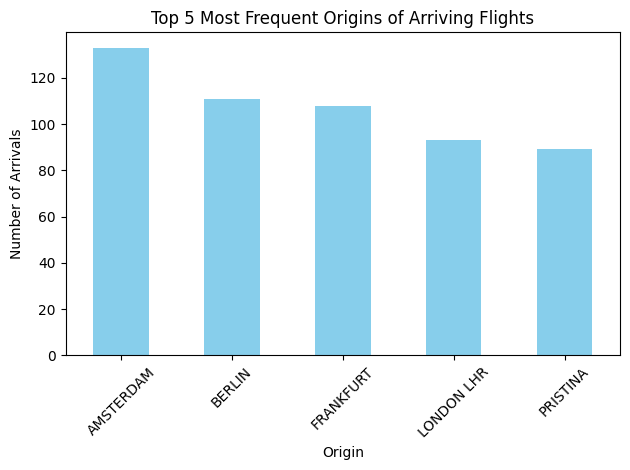

In [60]:
### AT ALL AIRPORTS COMBINED ###

# Find the top five most frequent origins
top_origins = df_airports_2w_arrivals['ForeignAirport'].value_counts().head(5)
# Display the result
print("Top 5 Most Frequent Origins of Arriving Flights:")
print(top_origins)

# Optional: plotting the top origins
top_origins.plot(kind='bar', color='skyblue')
plt.title("Top 5 Most Frequent Origins of Arriving Flights")
plt.xlabel("Origin")
plt.ylabel("Number of Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 5 Most Frequent Origins at Each Local Airport:
    LocalAirport           ForeignAirport  Frequency
91         BASEL                 PRISTINA         45
38         BASEL                FRANKFURT         37
4          BASEL                AMSTERDAM         36
63         BASEL          LONDON HEATHROW         36
87         BASEL  PARIS CHARLES DE GAULLE         29
169       GENEVA                   LONDON         33
190       GENEVA                    PORTO         20
129       GENEVA                BARCELONA         14
126       GENEVA                AMSTERDAM         13
168       GENEVA                   LISBON         13
283       ZURICH               LONDON LHR         93
221       ZURICH                   BERLIN         91
215       ZURICH                AMSTERDAM         84
254       ZURICH                FRANKFURT         63
357       ZURICH                   VIENNA         62


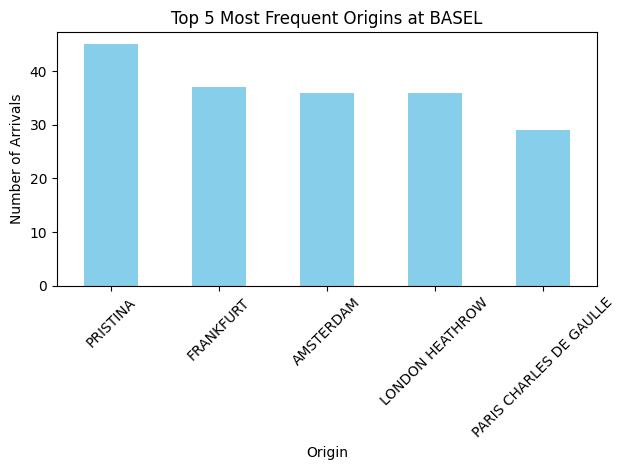

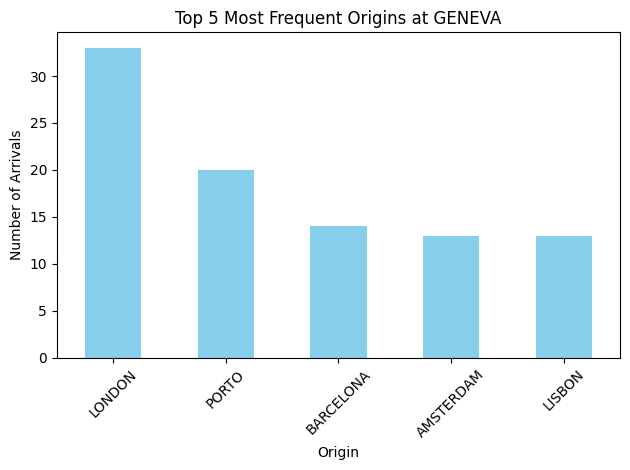

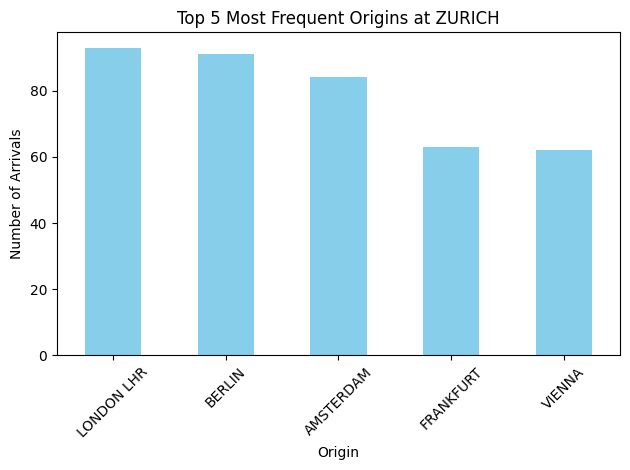

In [61]:
### AT EACH AIRPORT ###

# Group by 'LocalAirport' and 'ForeignAirport', then count occurrences
top_origins_per_airport = (
    df_airports_2w_arrivals.groupby(['LocalAirport', 'ForeignAirport'], observed=True)
    .size()
    .reset_index(name='Frequency')
)

# Sort each group by 'Frequency' in descending order and take the top 5
top_origins_per_airport = (
    top_origins_per_airport.sort_values(['LocalAirport', 'Frequency'], ascending=[True, False])
    .groupby('LocalAirport', observed=True)
    .head(5)
)

# Display the result
print("Top 5 Most Frequent Origins at Each Local Airport:")
print(top_origins_per_airport)

# Plotting each airport's top origins separately
for airport, data in top_origins_per_airport.groupby('LocalAirport', observed=True):
    data.plot(
        kind='bar',
        x='ForeignAirport',
        y='Frequency',
        legend=False,
        title=f"Top 5 Most Frequent Origins at {airport}",
        xlabel="Origin",
        ylabel="Number of Arrivals",
        color='skyblue'
    )
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### RQ 2: Top 5 airlines with the highest frequency of arrivals over the past 2 weeks

Top 5 Airlines by Arrival Frequency:
                 Number of Arrivals
Airline                            
SWISS                          1340
EASYJET                         588
EDELWEISS                       144
LUFTHANSA                       141
BRITISH AIRWAYS                 111


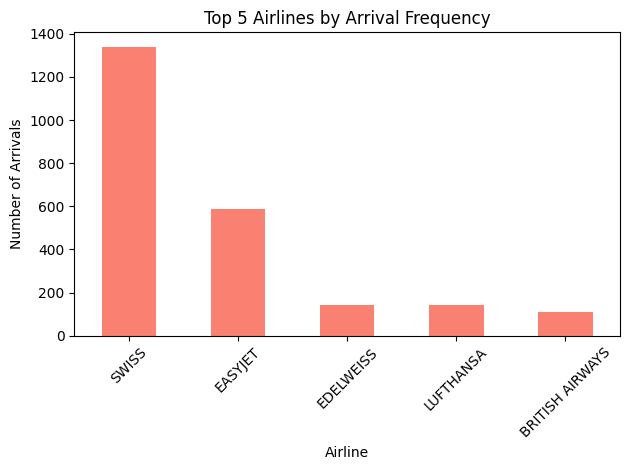

In [62]:
### AT ALL AIRPORTS COMBINED ###

top_airlines = df_airports_2w_arrivals['Airline'].value_counts().head(5)

# Display the result
print("Top 5 Airlines by Arrival Frequency:")
print(top_airlines.to_frame(name='Number of Arrivals'))

# Optional: plotting the top airlines
top_airlines.plot(kind='bar', color='salmon')
plt.title("Top 5 Airlines by Arrival Frequency")
plt.xlabel("Airline")
plt.ylabel("Number of Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top 5 Airlines by Arrival Frequency at Each of the Top 3 Local Airports:
    LocalAirport          Airline  Frequency
14         BASEL          EASYJET        362
40         BASEL         WIZZ AIR         69
26         BASEL        LUFTHANSA         63
11         BASEL  BRITISH AIRWAYS         36
25         BASEL              KLM         27
54        GENEVA          EASYJET        182
77        GENEVA            SWISS         41
52        GENEVA  BRITISH AIRWAYS         14
48        GENEVA     AIR DOLOMITI         10
49        GENEVA       AIR FRANCE          8
128       ZURICH            SWISS       1299
102       ZURICH        EDELWEISS        144
109       ZURICH        EUROWINGS         76
119       ZURICH        LUFTHANSA         72
93        ZURICH  BRITISH AIRWAYS         61


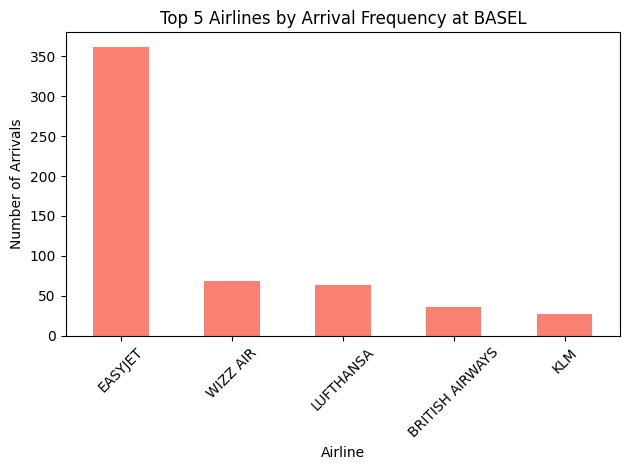

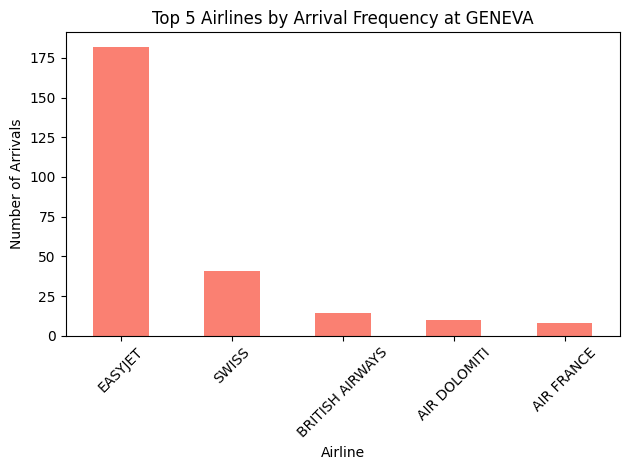

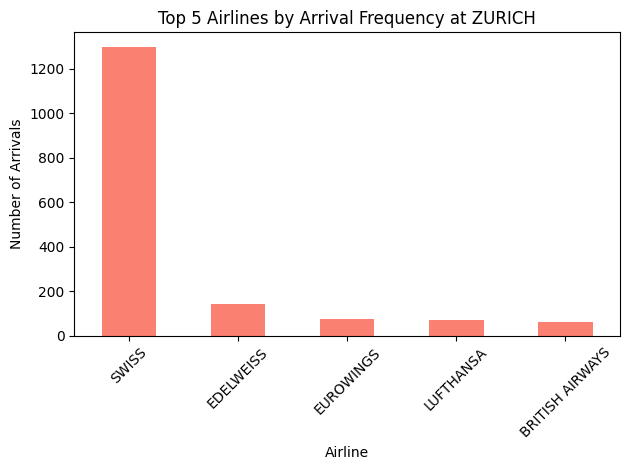

In [63]:
### AT EACH AIRPORT ###

# Step 1: Find the top 3 local airports by frequency of arrivals
top_local_airports = (
    df_airports_2w_arrivals['LocalAirport']
    .value_counts()
    .head(3)
    .index
)

# Step 2: Filter the data for only the top 3 local airports
filtered_df = df_airports_2w_arrivals[df_airports_2w_arrivals['LocalAirport'].isin(top_local_airports)]

# Step 3: Group by 'LocalAirport' and 'Airline', count frequencies, and take the top 5 airlines for each airport
top_airlines_per_airport = (
    filtered_df.groupby(['LocalAirport', 'Airline'], observed=True)
    .size()
    .reset_index(name='Frequency')
    .sort_values(['LocalAirport', 'Frequency'], ascending=[True, False])
    .groupby('LocalAirport', observed=True)
    .head(5)
)

# Display the result
print("Top 5 Airlines by Arrival Frequency at Each of the Top 3 Local Airports:")
print(top_airlines_per_airport)

# Plotting the top airlines for each local airport
for airport, data in top_airlines_per_airport.groupby('LocalAirport', observed=True):
    data.plot(
        kind='bar',
        x='Airline',
        y='Frequency',
        legend=False,
        title=f"Top 5 Airlines by Arrival Frequency at {airport}",
        xlabel="Airline",
        ylabel="Number of Arrivals",
        color='salmon'
    )
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### RQ 3: Average delay time for arrivals and departures

In [64]:
# Average delay for arrivals and departures
arrival_delays = df_airports_2w_arrivals['Delay'].mean()
departure_delays = df_airports_2w_departures['Delay'].mean()

print(f"Average delay of arriving flights: {arrival_delays:.2f} minutes")
print(f"Average delay of departing flights: {departure_delays:.2f} minutes")

# Comparison of delay across airports
punctuality_metrics = df_airports_2w.groupby(['LocalAirport', 'Type'], observed=True)['Delay'].mean().reset_index()
punctuality_metrics.columns = ['Airport', 'Type', 'AverageDelay']

print("Average delay by airport and flight type:")
display(punctuality_metrics)

Average delay of arriving flights: -0.16 minutes
Average delay of departing flights: 4.30 minutes
Average delay by airport and flight type:


,Airport,Type,AverageDelay
0,BASEL,ARRIVAL,-3.409478
1,BASEL,DEPARTURE,2.135006
2,GENEVA,ARRIVAL,-2.123894
3,GENEVA,DEPARTURE,2.108359
4,ZURICH,ARRIVAL,1.304615
5,ZURICH,DEPARTURE,5.385412


Summary of Delay Column for Arrivals after Removing IQR Outliers:
count    3329.000000
mean       -1.954941
std        10.567026
min       -37.000000
25%        -7.000000
50%        -3.000000
75%         2.000000
max        33.000000
Name: Delay, dtype: float64

Summary of Delay Column for Departures after Removing IQR Outliers:
count    3280.00000
mean        1.83628
std         5.46912
min       -15.00000
25%         0.00000
50%         0.00000
75%         0.00000
max        20.00000
Name: Delay, dtype: float64


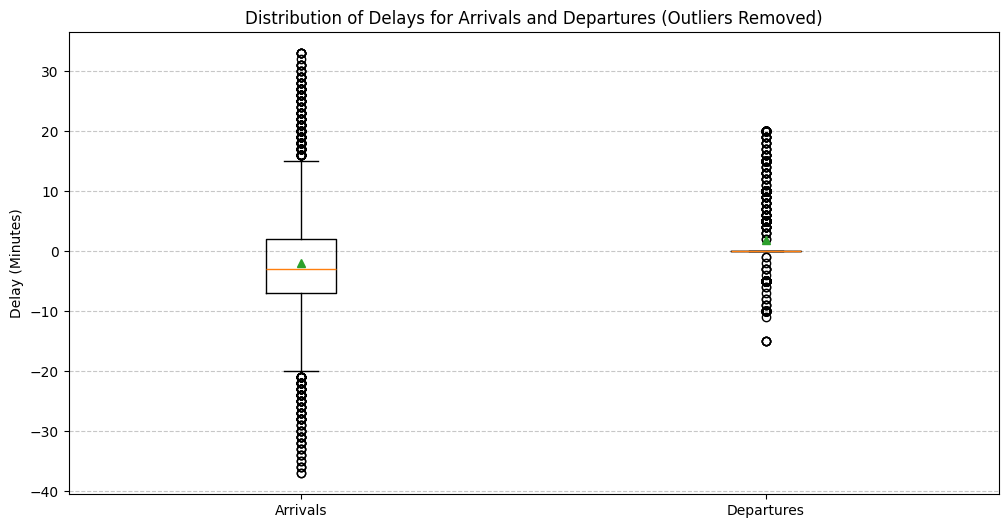

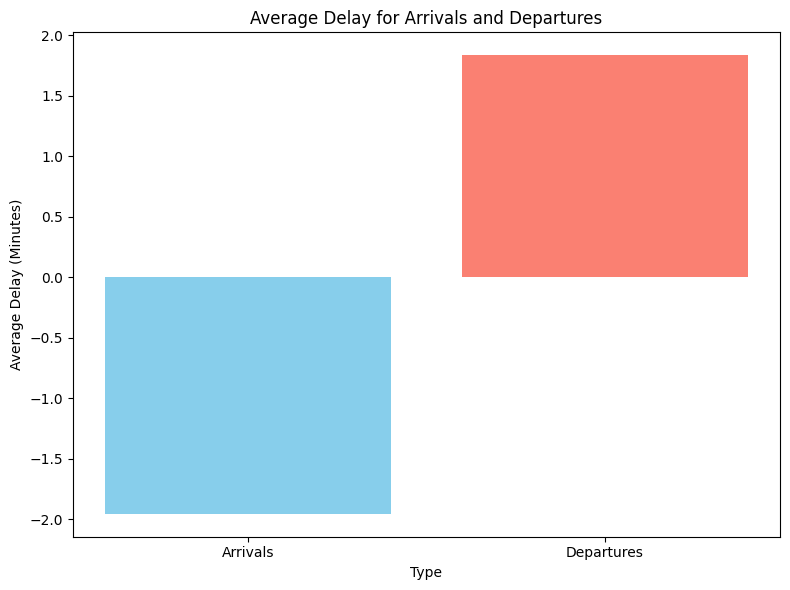

In [65]:
# Optional - let's ignore the outliers 

# ---- Arrivals ----
# Calculate IQR bounds for Arrivals
Q1_arrivals = df_airports_2w_arrivals['Delay'].quantile(0.25)
Q3_arrivals = df_airports_2w_arrivals['Delay'].quantile(0.75)
IQR_arrivals = Q3_arrivals - Q1_arrivals
lower_bound_arrivals = Q1_arrivals - 3 * IQR_arrivals
upper_bound_arrivals = Q3_arrivals + 3 * IQR_arrivals

# Filter out outliers for Arrivals
arrivals_cleaned = df_airports_2w_arrivals[(df_airports_2w_arrivals['Delay'] >= lower_bound_arrivals) & (df_airports_2w_arrivals['Delay'] <= upper_bound_arrivals)]

# ---- Departures ----
# Calculate IQR bounds for Departures
Q1_departures = df_airports_2w_departures['Delay'].quantile(0.25)
Q3_departures = df_airports_2w_departures['Delay'].quantile(0.75)
IQR_departures = Q3_departures - Q1_departures
lower_bound_departures = Q1_departures - 3 * IQR_departures
upper_bound_departures = Q3_departures + 3 * IQR_departures

# Filter out outliers for Departures
departures_cleaned = df_airports_2w_departures[(df_airports_2w_departures['Delay'] >= lower_bound_departures) & (df_airports_2w_departures['Delay'] <= upper_bound_departures)]

# ---- Combine arrivals and departures ----
# Combine the cleaned data for both types
df_cleaned = pd.concat([arrivals_cleaned, departures_cleaned])

# Display summary of the cleaned data to verify that outliers have been removed
print("Summary of Delay Column for Arrivals after Removing IQR Outliers:")
print(arrivals_cleaned['Delay'].describe())

print("\nSummary of Delay Column for Departures after Removing IQR Outliers:")
print(departures_cleaned['Delay'].describe())

# Plotting boxplot for Delay distributions after removing outliers
plt.figure(figsize=(12, 6))
plt.boxplot(
    [arrivals_cleaned['Delay'], departures_cleaned['Delay']],
    tick_labels=['Arrivals', 'Departures'],
    showmeans=True
)
plt.title("Distribution of Delays for Arrivals and Departures (Outliers Removed)")
plt.ylabel("Delay (Minutes)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Bar plot for Average Delay
average_delays = {
    'Arrivals': arrivals_cleaned['Delay'].mean(),
    'Departures': departures_cleaned['Delay'].mean()
}

plt.figure(figsize=(8, 6))
plt.bar(average_delays.keys(), average_delays.values(), color=['skyblue', 'salmon'])
plt.title("Average Delay for Arrivals and Departures")
plt.xlabel("Type")
plt.ylabel("Average Delay (Minutes)")
plt.tight_layout()
plt.show()


### BONUS: Top 10 most frequet airlines and their ranking on average delay time for arrivals and departures

Top 10 Airlines with Most Average Delay in Arrivals:
Airline
EUROWINGS           4.769231
KLM                 2.375000
LUFTHANSA           1.475177
SWISS               1.405224
EDELWEISS           0.645833
BRITISH AIRWAYS    -1.774775
EASYJET            -2.702381
WIZZ AIR           -3.478261
AIR FRANCE         -3.862745
TURKISH AIRLINES   -7.849057
Name: Delay, dtype: float64

Top 10 Airlines with Most Average Delay in Departures:
Airline
EUROWINGS           8.012821
EDELWEISS           7.390728
LUFTHANSA           6.407143
SWISS               4.821507
WIZZ AIR            3.885714
TURKISH AIRLINES    3.574074
KLM                 3.337838
EASYJET             1.764505
BRITISH AIRWAYS     1.442478
AIR FRANCE          0.754717
Name: Delay, dtype: float64


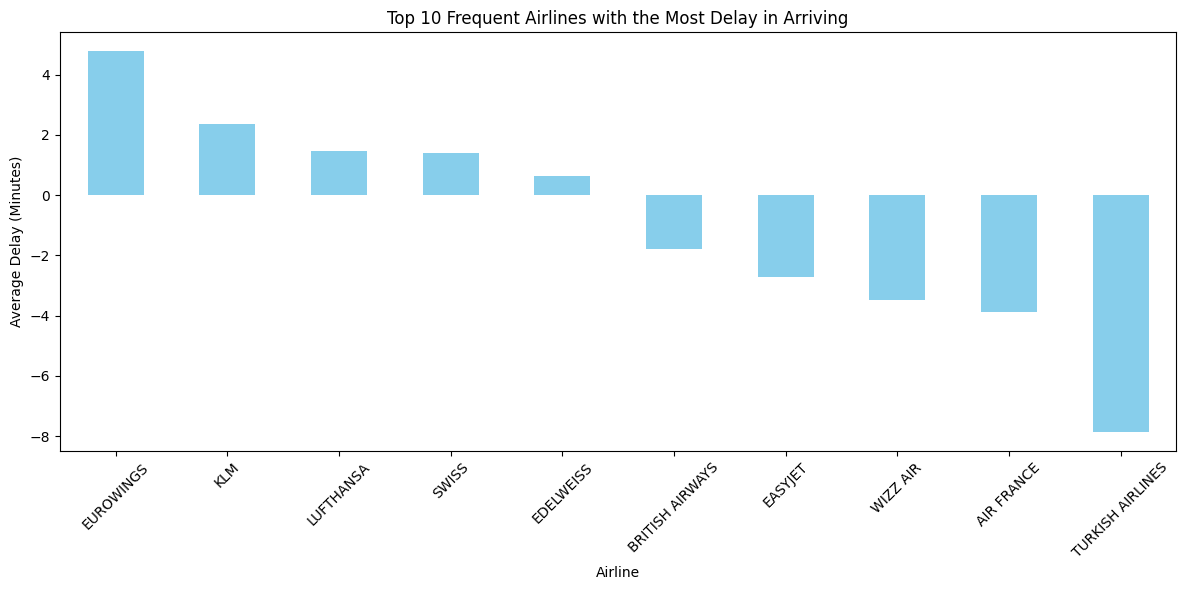

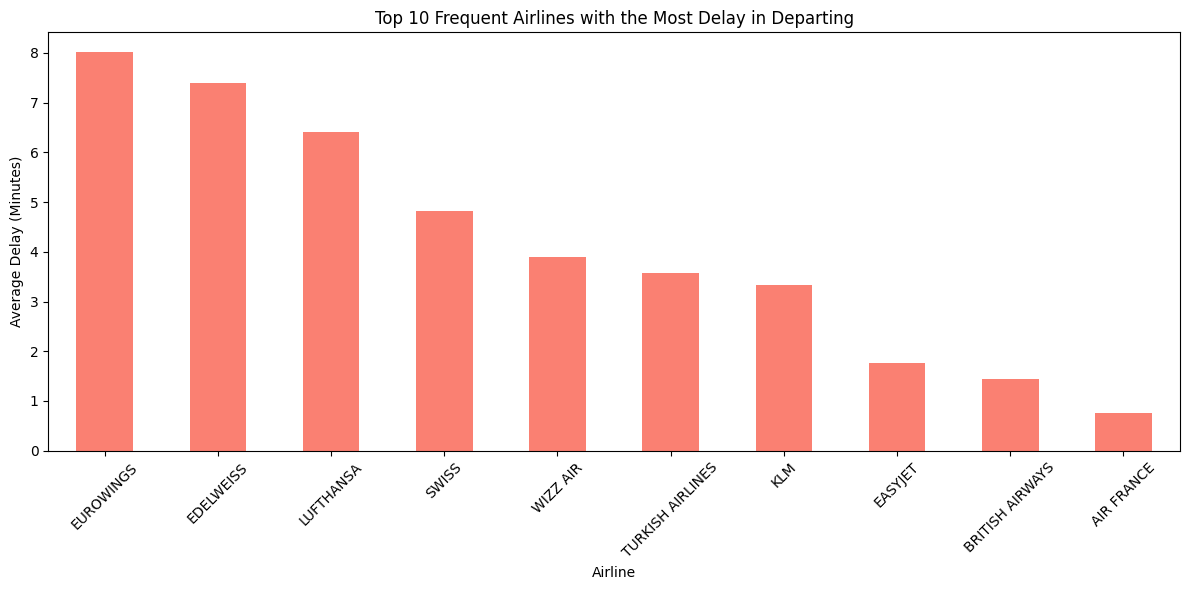

In [67]:
# Identify the top 10 airlines with the greatest frequency in arrivals
top_10_arrival_airlines = df_airports_2w_arrivals['Airline'].value_counts().head(10).index

# Identify the top 10 airlines with the greatest frequency in departures
top_10_departure_airlines = df_airports_2w_departures['Airline'].value_counts().head(10).index

# Combine these lists to get the union of airlines appearing in either top 10 list
top_airlines = top_10_arrival_airlines.union(top_10_departure_airlines)

# Filter the main DataFrame to only include rows for these top airlines
top_airlines_df = df_airports_2w[df_airports_2w['Airline'].isin(top_airlines)]

# Calculate the average delay grouped by Airline and Type
average_delay_by_airline_and_type = top_airlines_df.groupby(['Airline', 'Type'], observed=True)['Delay'].mean()

# Separate arrivals and departures, then rank them within each group
average_delay_arrivals = average_delay_by_airline_and_type.xs('ARRIVAL', level='Type').sort_values(ascending=False)
average_delay_departures = average_delay_by_airline_and_type.xs('DEPARTURE', level='Type').sort_values(ascending=False)

# Display the top 10 airlines with the most average delay in arrivals and departures
print("Top 10 Airlines with Most Average Delay in Arrivals:")
print(average_delay_arrivals.head(10))

print("\nTop 10 Airlines with Most Average Delay in Departures:")
print(average_delay_departures.head(10))

# Optional: plotting the results for Arrivals
plt.figure(figsize=(12, 6))
average_delay_arrivals.head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Frequent Airlines with the Most Delay in Arriving")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plotting the results for Departures
plt.figure(figsize=(12, 6))
average_delay_departures.head(10).plot(kind='bar', color='salmon')
plt.title("Top 10 Frequent Airlines with the Most Delay in Departing")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [47]:
# exporting the dataset for further use
df_airports.to_csv('./airports_final.csv', index=False)